In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Iris.csv")

In [3]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

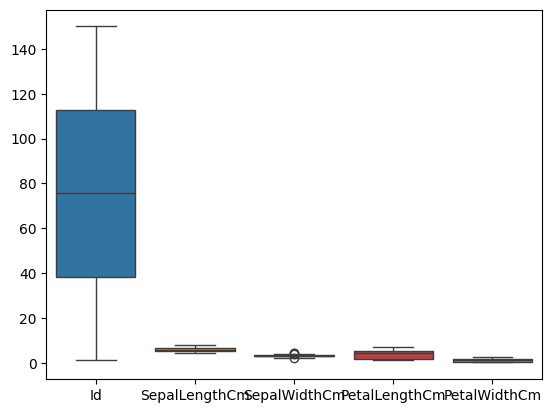

In [5]:
sns.boxplot(data = data)
plt.show()

In [6]:
q1 = data['SepalWidthCm'].quantile(0.25)
q3 = data['SepalWidthCm'].quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr

data = data[(data['SepalWidthCm'] >= lower) & (data['SepalWidthCm'] <= upper)]


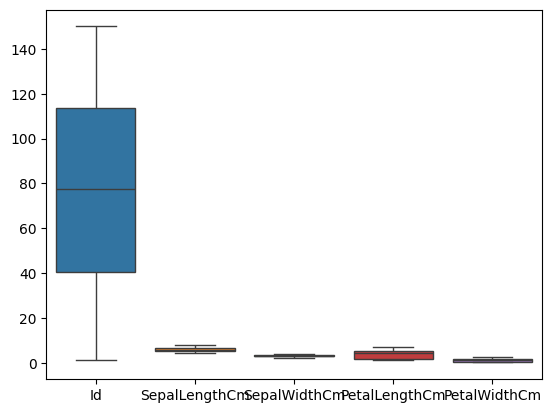

In [7]:
sns.boxplot(data = data)
plt.show()

In [8]:
data.groupby('Species').describe()

Id                                                       \
                count        mean        std    min     25%    50%     75%   
Species                                                                      
Iris-setosa      47.0   25.361702  14.885688    1.0   12.50   25.0   38.50   
Iris-versicolor  49.0   75.795918  14.575921   51.0   64.00   76.0   88.00   
Iris-virginica   50.0  125.500000  14.577380  101.0  113.25  125.5  137.75   

                       SepalLengthCm            ... PetalLengthCm       \
                   max         count      mean  ...           75%  max   
Species                                         ...                      
Iris-setosa       50.0          47.0  4.976596  ...         1.600  1.9   
Iris-versicolor  100.0          49.0  5.955102  ...         4.600  5.1   
Iris-virginica   150.0          50.0  6.588000  ...         5.875  6.9   

                PetalWidthCm                                               
                       count      mean       std  min  25%  50%  75%  max  
Species                                                                    
Iris-setosa             47.0  0.244681  0.105930  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor         49.0  1.332653  0.194066  1.0  1.2  1.3  1.5  1.8  
Iris-virginica          50.0  2.026000  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 40 columns]

In [10]:
stats = data.groupby('Species').agg(['mean', 'std'])

print("\nMean and Standard Deviation:\n")
print(stats)


Mean and Standard Deviation:

                         Id            SepalLengthCm           SepalWidthCm  \
                       mean        std          mean       std         mean   
Species                                                                       
Iris-setosa       25.361702  14.885688      4.976596  0.338932     3.365957   
Iris-versicolor   75.795918  14.575921      5.955102  0.503348     2.785714   
Iris-virginica   125.500000  14.577380      6.588000  0.635880     2.974000   

                          PetalLengthCm           PetalWidthCm            
                      std          mean       std         mean       std  
Species                                                                   
Iris-setosa      0.327890       1.46383  0.178673     0.244681  0.105930  
Iris-versicolor  0.296507       4.27551  0.461668     1.332653  0.194066  
Iris-virginica   0.322497       5.55200  0.551895     2.026000  0.274650  


In [12]:
percentile = data.groupby('Species').quantile([0.25, 0.5, 0.75])

print("\nPercentiles (25%, 50%, 75%):\n")
print(percentile)


Percentiles (25%, 50%, 75%):

                          Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Species                                                                    
Iris-setosa     0.25   12.50          4.800         3.100          1.400   
                0.50   25.00          5.000         3.400          1.500   
                0.75   38.50          5.100         3.550          1.600   
Iris-versicolor 0.25   64.00          5.600         2.600          4.000   
                0.50   76.00          5.900         2.800          4.400   
                0.75   88.00          6.300         3.000          4.600   
Iris-virginica  0.25  113.25          6.225         2.800          5.100   
                0.50  125.50          6.500         3.000          5.550   
                0.75  137.75          6.900         3.175          5.875   

                      PetalWidthCm  
Species                             
Iris-setosa     0.25           0.2  
                0.50 